# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Alumno:** Benjamín Cid Roblero <br>

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import seaborn as sns

### Algunas preguntas a responder:

1. ¿Cuántos condados ganó cada candidato?
1. ¿Hay diferencias en los ingresos per capita entre condados que votaron demócrata o republicano?
1. ¿Hay diferencias en el nivel educacional entre condados que votaron demócrata o republicano?
1. ¿Son homogéneos los estados D/R en cuanto a ingresos, desempleo, educación?

<div class="alert alert-block alert-info">
<b> Desafío:</b> Contesten las cuatro preguntas anteriores con los datos de la base usada.
    
<b>Los estudiantes que me envíen un Jupyter Notebook antes del viernes, contestando correctamente estas preguntas, tendrán +0.3 en la Interrogación 1.</b>
</div>

In [3]:
dat = pd.read_csv('county_election_results.csv')

#caculamos el porcentaje de votos D y R en cada condado, para identificar más fácilmente quién ganó en cada uno
dat['pct_D'] = dat['votes_D_2020']/dat['votes_total_2020']*100
dat['pct_R'] = dat['votes_R_2020']/dat['votes_total_2020']*100

dat.head()

,Unnamed: 0,FIPS,eevp,electTotal,electionDate,level,office,state,winner,votes_R_2020,...,votes_2008,votes_2012,votes_2016,category_2016_dem,category_2016_rep,votes_d_2016,votes_r_2016,votes_cast_pct_2016,pct_D,pct_R
0,0,1061,100,0,2020-11-03,FIPSCode,presidential,AL,R,10848,...,11657,11320,11758,NaN,top 10% Trump by percent vote,1525,9994,1.065913,12.726402,86.555493
1,1,1021,100,0,2020-11-03,FIPSCode,presidential,AL,R,16085,...,17785,17462,18369,NaN,top 10% Trump by percent vote,2911,15081,1.049649,15.937970,83.424096
2,2,1049,100,0,2020-11-03,FIPSCode,presidential,AL,R,24767,...,24015,23863,25826,NaN,top 10% Trump by percent vote,3622,21405,1.134438,14.611919,84.534781
3,3,1093,100,0,2020-11-03,FIPSCode,presidential,AL,R,12205,...,12355,12105,12984,NaN,top 10% Trump by percent vote,1432,11274,1.061537,10.614525,88.551114
4,4,1059,100,0,2020-11-03,FIPSCode,presidential,AL,R,10376,...,11693,10859,12040,NaN,NaN,2197,9466,1.043854,16.597708,82.558880


In [4]:
columns = ['pct_D','pct_R','acs_pct_pop_nonwhite', 'acs_pct_management', 'acs_pct_service',
       'pct_pop25+_bachelor_higher', 'median_household_income',
       'per_capita_income','POPESTIMATE2019','state','county','Unemployment Rate','winner','region']
dat2 = dat[columns]

In [5]:
dat2.columns

Index(['pct_D', 'pct_R', 'acs_pct_pop_nonwhite', 'acs_pct_management',
       'acs_pct_service', 'pct_pop25+_bachelor_higher',
       'median_household_income', 'per_capita_income', 'POPESTIMATE2019',
       'state', 'county', 'Unemployment Rate', 'winner', 'region'],
      dtype='object')

### Respuesta a la pregunta 1:

In [7]:
wins_condado = dat2['winner'].value_counts()
wins_condado

winner
R    1965
D    1147
Name: count, dtype: int64

### Respuesta a la pregunta 2:

In [10]:
#Agrupo el dataframe por el ganador del condado y descrbimos la columna per_capita_income de cada partido
display((dat2.groupby('winner')['per_capita_income'].describe()).round(2))
print(f'Se puede evidenciar que la diferencia de ingresos per cápita es considerable, de hasta ${round(29212.22 - 25675.98, 2)} dólares.\nAdemás, los Demócratas tienen un maximo por condado mayor a los Republicanos (US $72832.0 versus $53950.0).')

,count,mean,std,min,25%,50%,75%,max
winner,,,,,,,,
D,1146.0,29212.22,7590.08,12292.0,24430.25,28052.0,32521.0,72832.0
R,1965.0,25675.98,5292.41,10148.0,22106.00,25127.0,28732.0,53950.0


Se puede evidenciar que la diferencia de ingresos per cápita es considerable, de hasta $3536.24 dólares.
Además, los Demócratas tienen un maximo por condado mayor a los Republicanos (US $72832.0 versus $53950.0).


### Respuesta a la pregunta 3:

In [13]:
display(dat2.groupby('winner')['pct_pop25+_bachelor_higher'].describe())

,count,mean,std,min,25%,50%,75%,max
winner,,,,,,,,
D,1147.0,24.637140,11.02384,7.0,16.6,21.8,30.4,78.5
R,1965.0,19.761323,7.83282,0.0,14.3,18.1,23.2,59.0


Se puede evidenciar que el nivel de educación entre los votantes Demócratas y Republicano no es menor, los liberales superan por un 4.87% más el nivel de estudios a los conservadores.

### Respuesta a la pregunta final:

In [37]:
# Agrupar por 'winner' y calcular estadísticas descriptivas para ingresos, desempleo y educación
homogeneity_stats = dat2.groupby('winner')[['per_capita_income', 'Unemployment Rate', 'pct_pop25+_bachelor_higher']].describe()

print("Estadísticas descriptivas por ganador (D/R):")
print("Ingreso per cápita:")
display((homogeneity_stats['per_capita_income']).round(2))
print("Tasa de desempleo:")
display((homogeneity_stats['Unemployment Rate']).round(2))
print("Nivel de estudios:")
display((homogeneity_stats['pct_pop25+_bachelor_higher']).round(2))



Estadísticas descriptivas por ganador (D/R):
Ingreso per cápita:


,count,mean,std,min,25%,50%,75%,max
winner,,,,,,,,
D,1146.0,29212.22,7590.08,12292.0,24430.25,28052.0,32521.0,72832.0
R,1965.0,25675.98,5292.41,10148.0,22106.00,25127.0,28732.0,53950.0


Tasa de desempleo:


,count,mean,std,min,25%,50%,75%,max
winner,,,,,,,,
D,1147.0,7.28,2.63,2.0,5.4,6.9,8.8,22.9
R,1965.0,6.23,2.36,0.4,4.7,6.0,7.5,20.8


Nivel de estudios:


,count,mean,std,min,25%,50%,75%,max
winner,,,,,,,,
D,1147.0,24.64,11.02,7.0,16.6,21.8,30.4,78.5
R,1965.0,19.76,7.83,0.0,14.3,18.1,23.2,59.0


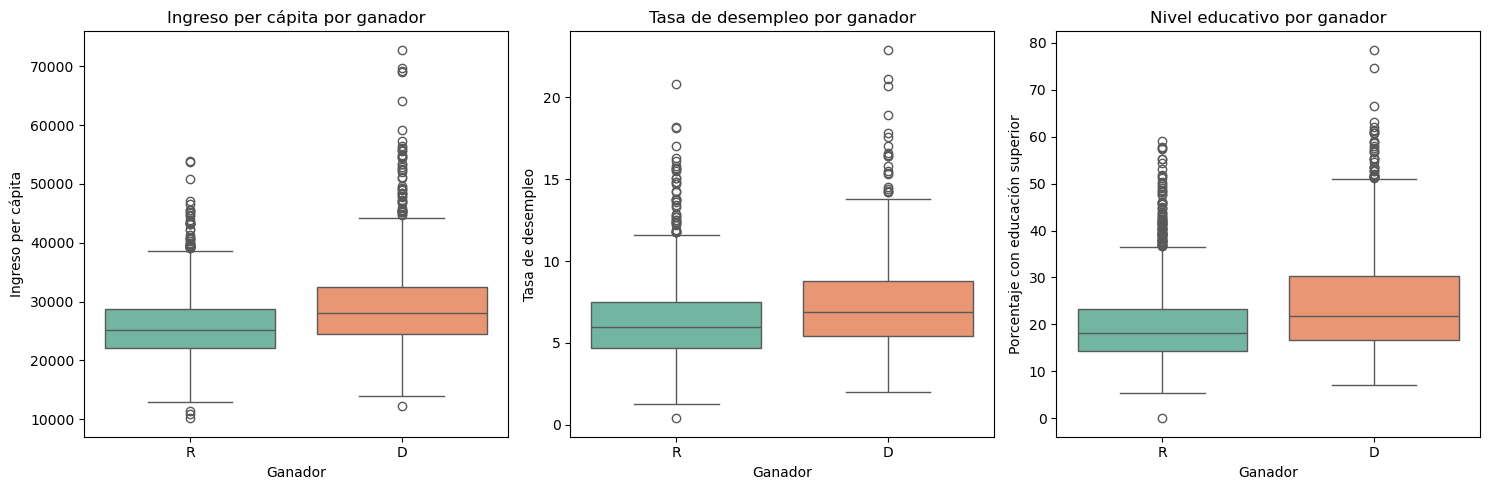

In [28]:

# Visualizar las diferencias con gráficos de caja
plt.figure(figsize=(15, 5))

#Ingreso per cápita
plt.subplot(1, 3, 1)
sns.boxplot(data=dat2, x='winner', y='per_capita_income', hue='winner', palette='Set2', dodge=False)
plt.title("Ingreso per cápita por ganador")
plt.xlabel("Ganador")
plt.ylabel("Ingreso per cápita")

#Tasa de desempleo
plt.subplot(1, 3, 2)
sns.boxplot(data=dat2, x='winner', y='Unemployment Rate', hue='winner', palette='Set2', dodge=False)
plt.title("Tasa de desempleo por ganador")
plt.xlabel("Ganador")
plt.ylabel("Tasa de desempleo")

#Nivel educativo
plt.subplot(1, 3, 3)
sns.boxplot(data=dat2, x='winner', y='pct_pop25+_bachelor_higher', hue='winner', palette='Set2', dodge=False)
plt.title("Nivel educativo por ganador")
plt.xlabel("Ganador")
plt.ylabel("Porcentaje con educación superior")

plt.tight_layout()
plt.show()

En base al gráfico y variables descriptivas, notamos que los condados Demócratas (D) y Republicanos (R) muestran una clara falta de homogeneidad tanto entre sí como internamente en variables clave como ingresos, desempleo y educación. La heterogeneidad entre grupos es evidente en los promedios: los condados Demócratas son, en conjunto, más ricos y más educados que los Republicanos. Sin embargo, la heterogeneidad interna es confirmada por los diagramas de caja y bigotes, donde los valores atípicos **(outliers)** y el ancho de la caja indican una gran dispersión de datos dentro de cada partido. Esto evidencia la diferencia de clases sociales presentes en el país americano.